In [2]:
# ── Install all required packages ────────────────────────────────────────────
!pip install -q kagglehub albumentations tensorflowjs opencv-python-headless \
               matplotlib seaborn scikit-learn tqdm gdown Pillow

import os, shutil, random, zipfile, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
import tensorflowjs as tfjs
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.40.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
db-dtypes 1.5.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.


✅ Using device: cpu


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ── Base directories ──────────────────────────────────────────────────────────
BASE_DIR     = Path('/content/spoof_detection')
RAW_DIR      = BASE_DIR / 'raw'
DATASET_DIR  = BASE_DIR / 'dataset'
REAL_DIR     = DATASET_DIR / 'real'
SPOOF_DIR    = DATASET_DIR / 'spoof'
MODELS_DIR   = BASE_DIR / 'models'
EXPORT_DIR   = BASE_DIR / 'export'

for d in [RAW_DIR, REAL_DIR, SPOOF_DIR, MODELS_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('✅ Directories created:')
for d in [REAL_DIR, SPOOF_DIR, MODELS_DIR, EXPORT_DIR]:
    print(f'   {d}')

Mounted at /content/drive
✅ Directories created:
   /content/spoof_detection/dataset/real
   /content/spoof_detection/dataset/spoof
   /content/spoof_detection/models
   /content/spoof_detection/export


In [4]:
# ── You need a Kaggle API key. Upload kaggle.json or set env vars ─────────────
# Option A: Upload kaggle.json
# from google.colab import files
# files.upload()   # upload your kaggle.json here
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# Option B: Paste credentials directly (replace with your own)
import os
os.environ['KAGGLE_USERNAME'] = 'YOUR_KAGGLE_USERNAME'   # ← replace
os.environ['KAGGLE_KEY']      = 'YOUR_KAGGLE_API_KEY'    # ← replace

import kagglehub
muzzle_path = kagglehub.dataset_download('sharifashik/cow-muzzle-dataset')
print(f'Downloaded to: {muzzle_path}')

# ── Collect all image files from the downloaded dataset ──────────────────────
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
muzzle_images = [
    p for p in Path(muzzle_path).rglob('*')
    if p.suffix.lower() in VALID_EXTS
]
print(f'Found {len(muzzle_images)} muzzle images')

# ── Copy to REAL_DIR ──────────────────────────────────────────────────────────
real_count = 0
for i, src in enumerate(tqdm(muzzle_images, desc='Copying real muzzle images')):
    dst = REAL_DIR / f'muzzle_real_{i:05d}{src.suffix.lower()}'
    shutil.copy2(src, dst)
    real_count += 1

print(f'✅ {real_count} real muzzle images copied to {REAL_DIR}')

100%|██████████| 67.9M/67.9M [00:00<00:00, 161MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/sharifashik/cow-muzzle-dataset/versions/1
Found 1455 muzzle images


Copying real muzzle images:   0%|          | 0/1455 [00:00<?, ?it/s]

✅ 1455 real muzzle images copied to /content/spoof_detection/dataset/real


In [5]:
import shutil
import kagglehub
from pathlib import Path
from tqdm import tqdm

# 1. Download the dataset dynamically
# This will return the path to the downloaded files (usually in ~/.cache/kagglehub)
download_path = kagglehub.dataset_download("aleksandrpikul222/nuaaaa")
nuaa_download_dir = Path(download_path)

print(f"✅ Dataset downloaded to: {nuaa_download_dir}")

# Define your output directories (Ensure these are defined in your environment)
# REAL_DIR = Path('./data/real')
# SPOOF_DIR = Path('./data/spoof')
REAL_DIR.mkdir(parents=True, exist_ok=True)
SPOOF_DIR.mkdir(parents=True, exist_ok=True)

def load_nuaa_from_folder(src_root: Path, out_real: Path, out_spoof: Path):
    if not src_root.exists():
        print(f'⚠️  Source directory {src_root} does not exist.')
        return 0, 0

    real_n = spoof_n = 0
    print('Scanning for images...')

    # 1. Process Real Images (Checks for both 'ClientRaw' and 'ClientFace')
    real_images = list(src_root.rglob('ClientRaw/**/*.jpg')) + list(src_root.rglob('ClientFace/**/*.jpg'))
    if real_images:
        for src in tqdm(real_images, desc='NUAA real'):
            dst = out_real / f'nuaa_real_{real_n:05d}.jpg'
            shutil.copy2(src, dst)
            real_n += 1
    else:
        print("ℹ️ No real images found in the specified subfolders.")

    # 2. Process Spoof Images (Checks for both 'ImposterRaw' and 'ImposterFace')
    spoof_images = list(src_root.rglob('ImposterRaw/**/*.jpg')) + list(src_root.rglob('ImposterFace/**/*.jpg'))
    if spoof_images:
        for src in tqdm(spoof_images, desc='NUAA spoof'):
            dst = out_spoof / f'nuaa_spoof_{spoof_n:05d}.jpg'
            shutil.copy2(src, dst)
            spoof_n += 1
    else:
        print("ℹ️ No spoof images found in the specified subfolders.")

    return real_n, spoof_n

# Execute
n_real, n_spoof = load_nuaa_from_folder(nuaa_download_dir, REAL_DIR, SPOOF_DIR)

print(f'\n📊 Updated Dataset Status:')
print(f'   NUAA added: +{n_real} real, +{n_spoof} spoof')
print(f'   TOTAL REAL:  {len(list(REAL_DIR.glob("*.jpg")))}')
print(f'   TOTAL SPOOF: {len(list(SPOOF_DIR.glob("*.jpg")))}')

100%|██████████| 381M/381M [00:02<00:00, 186MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/aleksandrpikul222/nuaaaa/versions/1
Scanning for images...


NUAA spoof: 100%|██████████| 7509/7509 [00:01<00:00, 4632.61it/s]



📊 Updated Dataset Status:
   NUAA added: +5105 real, +7509 spoof
   TOTAL REAL:  6560
   TOTAL SPOOF: 7509


In [11]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input


In [ ]:
import albumentations as A
import numpy as np
import cv2
import random  # Added this import for your generation loop
from pathlib import Path
from tqdm.notebook import tqdm

# ── Spoof simulation transforms ───────────────────────────────────────────────

def add_moire_pattern(image: np.ndarray, frequency: float = 0.08) -> np.ndarray:
    """Simulate moiré pattern seen when photographing a screen."""
    h, w = image.shape[:2]
    x = np.arange(w)
    y = np.arange(h)
    X, Y = np.meshgrid(x, y)
    # Two interfering sine waves at slightly different angles
    pattern1 = np.sin(2 * np.pi * frequency * X) * np.sin(2 * np.pi * frequency * Y)
    pattern2 = np.sin(2 * np.pi * frequency * 1.05 * X + 0.3)
    moire = ((pattern1 + pattern2) * 0.5 + 0.5)  # normalize to [0, 1]
    moire = (moire * 18 - 9).astype(np.int16)     # ±9 pixel value shift
    result = np.clip(image.astype(np.int16) + moire[:, :, np.newaxis], 0, 255).astype(np.uint8)
    return result

def add_screen_pixel_grid(image: np.ndarray, pixel_size: int = 3) -> np.ndarray:
    """Add subtle RGB sub-pixel grid visible in close screen photos."""
    result = image.copy().astype(np.float32)
    # Darken every pixel_size-th row/col slightly to simulate pixel borders
    result[::pixel_size, :] *= 0.92
    result[:, ::pixel_size] *= 0.92
    return np.clip(result, 0, 255).astype(np.uint8)

def add_halftone(image: np.ndarray, dot_size: int = 4) -> np.ndarray:
    """Simulate printed halftone dot pattern."""
    result = image.copy()
    h, w = image.shape[:2]
    for y in range(0, h, dot_size * 2):
        for x in range(0, w, dot_size * 2):
            # Sample mean brightness of patch
            patch = image[y:y+dot_size*2, x:x+dot_size*2]
            if patch.size == 0: continue
            brightness = patch.mean() / 255.0
            # Smaller dots for bright areas, bigger for dark (halftone logic)
            radius = max(1, int((1 - brightness) * dot_size))
            cy, cx = y + dot_size, x + dot_size
            cv2.circle(result, (cx, cy), radius, (0, 0, 0), -1)
    return result

def add_paper_texture(image: np.ndarray, strength: float = 0.08) -> np.ndarray:
    """Add paper fiber noise texture."""
    noise = np.random.normal(0, strength * 255, image.shape).astype(np.int16)
    # Paper texture is more directional — add horizontal bias
    noise = cv2.GaussianBlur(noise.astype(np.float32), (1, 5), 0).astype(np.int16)
    return np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)

def add_vignetting(image: np.ndarray, sigma: float = 0.4) -> np.ndarray:
    """Add vignetting effect (darkened corners) to simulate camera lens."""
    h, w = image.shape[:2]
    X = cv2.getGaussianKernel(w, w * sigma)
    Y = cv2.getGaussianKernel(h, h * sigma)
    kernel = Y * X.T
    mask = kernel / kernel.max()
    result = image * mask[:, :, np.newaxis]
    return np.clip(result, 0, 255).astype(np.uint8)


# ── Screen attack augmentation pipeline ──────────────────────────────────────
screen_aug = A.Compose([
    # Simulate photographing a screen at a slight angle
    A.Perspective(scale=(0.02, 0.06), p=0.7),
    # Screen color temperature (cooler/bluer)
    A.RGBShift(r_shift_limit=(-15, 5), g_shift_limit=(-5, 5), b_shift_limit=(5, 20), p=0.8),
    # Screen brightness variation
    A.RandomBrightnessContrast(brightness_limit=(-0.1, 0.2), contrast_limit=(-0.1, 0.1), p=0.8),
    # Slight defocus from camera auto-focus on screen
    A.GaussianBlur(blur_limit=(3, 5), p=0.5),
    # Camera motion during phone-photographing-screen
    A.MotionBlur(blur_limit=5, p=0.3),
    # JPEG re-compression (screen photo saved as JPEG)
    A.ImageCompression(quality_lower=65, quality_upper=85, p=0.9),
])

# ── Print attack augmentation pipeline ───────────────────────────────────────
print_aug = A.Compose([
    # Photographing a printed paper at slight angle
    A.Perspective(scale=(0.02, 0.08), p=0.8),
    # Ink color loss (printers desaturate slightly)
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=(-30, -10), val_shift_limit=(-10, 10), p=0.85),
    # Paper yellowing / ambient color cast
    A.RGBShift(r_shift_limit=(0, 15), g_shift_limit=(0, 10), b_shift_limit=(-15, 0), p=0.7),
    # Paper flatness → slight contrast loss
    A.RandomBrightnessContrast(brightness_limit=(-0.05, 0.1), contrast_limit=(-0.2, -0.05), p=0.8),
    # Scan / re-photograph sharpness loss
    A.GaussianBlur(blur_limit=(3, 7), p=0.6),
    # Heavy JPEG compression from printer driver + re-photograph
    A.ImageCompression(quality_lower=55, quality_upper=78, p=0.95),
    # Noise from camera photographing under office fluorescent light
    A.GaussNoise(var_limit=(10, 40), p=0.6),
])

# ── Photo-of-photo attack pipeline ────────────────────────────────────────────
photo_of_photo_aug = A.Compose([
    A.Perspective(scale=(0.04, 0.10), p=0.9),
    A.ImageCompression(quality_lower=40, quality_upper=65, p=1.0),  # double compression
    A.GaussianBlur(blur_limit=(5, 9), p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.8),
    A.GaussNoise(var_limit=(20, 60), p=0.7),
])


def generate_synthetic_spoofs(
    real_dir: Path,
    spoof_dir: Path,
    target_spoof_count: int = None,
    spoofs_per_image: int = 3
):
    """
    For each real muzzle image, generate 3 synthetic spoof variants:
      1. Screen replay simulation
      2. Print attack simulation
      3. Photo-of-photo simulation + custom texture overlay
    """
    real_images = list(real_dir.glob('muzzle_real_*')) # only muzzle images, not face
    print(f'Generating synthetic spoofs from {len(real_images)} real muzzle images...')

    generated = 0
    for img_path in tqdm(real_images, desc='Synthetic spoof generation'):
        img = cv2.imread(str(img_path))
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ── Variant 1: Screen replay ────────────────────────────────────────
        aug1 = screen_aug(image=img_rgb)['image']

        # Manually trigger Vignetting logic exactly as intended
        if random.random() < 0.5:
            aug1 = add_vignetting(aug1, sigma=0.4)

        aug1 = add_moire_pattern(aug1, frequency=random.uniform(0.05, 0.12))
        aug1 = add_screen_pixel_grid(aug1, pixel_size=random.choice([2, 3, 4]))
        out1 = cv2.cvtColor(aug1, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(spoof_dir / f'synth_screen_{generated:06d}.jpg'), out1, [cv2.IMWRITE_JPEG_QUALITY, 80])
        generated += 1

        # ── Variant 2: Print attack ─────────────────────────────────────────
        aug2 = print_aug(image=img_rgb)['image']
        if random.random() > 0.5:
            aug2 = add_halftone(aug2, dot_size=random.choice([3, 4, 5]))
        aug2 = add_paper_texture(aug2, strength=random.uniform(0.04, 0.10))
        out2 = cv2.cvtColor(aug2, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(spoof_dir / f'synth_print_{generated:06d}.jpg'), out2, [cv2.IMWRITE_JPEG_QUALITY, 75])
        generated += 1

        # ── Variant 3: Photo of photo ────────────────────────────────────────
        aug3 = photo_of_photo_aug(image=img_rgb)['image']

        # Manually trigger Vignetting logic exactly as intended
        if random.random() < 0.6:
            aug3 = add_vignetting(aug3, sigma=0.5)

        out3 = cv2.cvtColor(aug3, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(spoof_dir / f'synth_photo_{generated:06d}.jpg'), out3, [cv2.IMWRITE_JPEG_QUALITY, 70])
        generated += 1

    print(f'✅ Generated {generated} synthetic spoof images')
    return generated

synth_count = generate_synthetic_spoofs(REAL_DIR, SPOOF_DIR)

print(f'\n📊 Final Dataset:')
print(f'   REAL  images: {len(list(REAL_DIR.glob("*")))}')
print(f'   SPOOF images: {len(list(SPOOF_DIR.glob("*")))}')

Generating synthetic spoofs from 1455 real muzzle images...


Synthetic spoof generation:   0%|          | 0/1455 [00:00<?, ?it/s]

REAL:  6560 images
SPOOF: 11874 images
Ratio: 0.55  (ideal: 0.8 – 1.2)


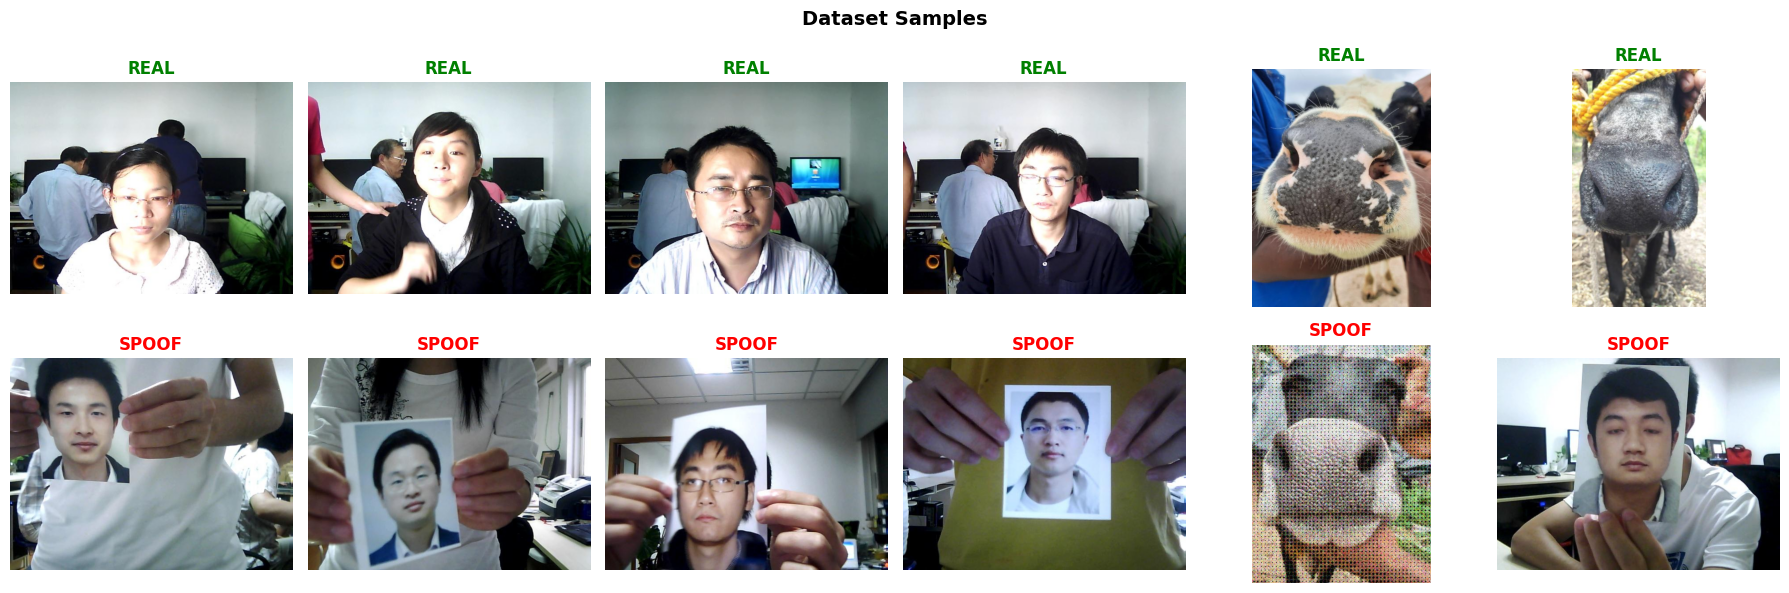

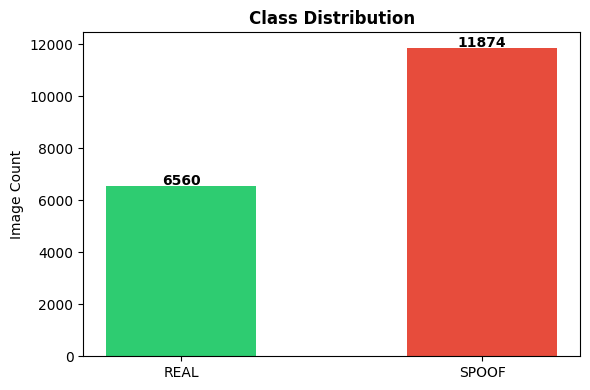

In [14]:
real_files  = list(REAL_DIR.glob('*'))
spoof_files = list(SPOOF_DIR.glob('*'))

print(f'REAL:  {len(real_files)} images')
print(f'SPOOF: {len(spoof_files)} images')
ratio = len(real_files) / max(len(spoof_files), 1)
print(f'Ratio: {ratio:.2f}  (ideal: 0.8 – 1.2)')

# ── Visual sample ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Dataset Samples', fontsize=14, fontweight='bold')

for i, fpath in enumerate(random.sample(real_files, min(6, len(real_files)))):
    img = cv2.cvtColor(cv2.imread(str(fpath)), cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img); axes[0, i].set_title('REAL', color='green', fontweight='bold')
    axes[0, i].axis('off')

for i, fpath in enumerate(random.sample(spoof_files, min(6, len(spoof_files)))):
    img = cv2.cvtColor(cv2.imread(str(fpath)), cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img); axes[1, i].set_title('SPOOF', color='red', fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(str(MODELS_DIR / 'dataset_samples.png'), dpi=120, bbox_inches='tight')
plt.show()

# ── Class distribution bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['REAL', 'SPOOF'], [len(real_files), len(spoof_files)],
               color=['#2ecc71', '#e74c3c'], width=0.5)
for bar, count in zip(bars, [len(real_files), len(spoof_files)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha='center', fontweight='bold')
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Image Count')
plt.tight_layout()
plt.show()

In [18]:
# ── Build file list with labels ───────────────────────────────────────────────
all_files  = [(str(f), 0) for f in real_files] + [(str(f), 1) for f in spoof_files]
random.shuffle(all_files)

paths  = [x[0] for x in all_files]
labels = [x[1] for x in all_files]

# Stratified 70 / 15 / 15 split
tr_p, tmp_p, tr_l, tmp_l = train_test_split(paths, labels, test_size=0.30,
                                              stratify=labels, random_state=SEED)
va_p, te_p, va_l, te_l   = train_test_split(tmp_p, tmp_l, test_size=0.50,
                                              stratify=tmp_l, random_state=SEED)

print(f'Train: {len(tr_p)}  |  Val: {len(va_p)}  |  Test: {len(te_p)}')
print(f'Train REAL/SPOOF: {tr_l.count(0)}/{tr_l.count(1)}')

# ── Albumentations transforms ─────────────────────────────────────────────────
IMG_SIZE = 224   # MobileNetV3 standard input

train_transform = A.Compose([
    # RandomResizedCrop requires 'size' as a tuple in recent versions
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.7, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.Rotate(limit=15, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.6),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5)),
        A.MotionBlur(blur_limit=5),
        A.MedianBlur(blur_limit=5),
    ], p=0.3),
    A.OneOf([
        A.GaussNoise(var_limit=(5, 25)),
        A.ISONoise(color_shift=(0.01, 0.05)),
    ], p=0.3),
    A.ImageCompression(quality_lower=70, quality_upper=100, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    # Resize still requires explicit 'height' and 'width' parameters
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])


class SpoofDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        if img is None:
            # Return a black image if file is corrupted
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)['image']

        return img, torch.tensor(self.labels[idx], dtype=torch.long)


# ── Weighted sampler to handle class imbalance ────────────────────────────────
class_counts  = [tr_l.count(0), tr_l.count(1)]
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[l] for l in tr_l]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_ds = SpoofDataset(tr_p, tr_l, train_transform)
val_ds   = SpoofDataset(va_p, va_l, val_transform)
test_ds  = SpoofDataset(te_p, te_l, val_transform)

BATCH_SIZE = 32
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ DataLoaders ready')
print(f'   Train batches: {len(train_dl)}  |  Val: {len(val_dl)}  |  Test: {len(test_dl)}')

Train: 12903  |  Val: 2765  |  Test: 2766
Train REAL/SPOOF: 4592/8311
✅ DataLoaders ready
   Train batches: 404  |  Val: 87  |  Test: 87


In [19]:
class MuzzleSpoofDetector(nn.Module):
    """
    MobileNetV3-Small backbone with a custom binary classification head.

    Architecture:
        MobileNetV3-Small (ImageNet pretrained)
            └── Custom head:
                  AdaptiveAvgPool2d
                  Flatten
                  Linear(576 → 256) + Hardswish + Dropout(0.3)
                  Linear(256 → 64)  + Hardswish + Dropout(0.2)
                  Linear(64  → 2)   → softmax
    """
    def __init__(self, dropout: float = 0.3, freeze_backbone: bool = True):
        super().__init__()

        backbone = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

        # ── Keep the feature extractor, replace the classifier ────────────
        self.features   = backbone.features
        self.avgpool    = backbone.avgpool

        # MobileNetV3-Small feature dim = 576
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(576, 256),
            nn.Hardswish(),
            nn.Dropout(p=dropout),
            nn.Linear(256, 64),
            nn.Hardswish(),
            nn.Dropout(p=dropout * 0.67),
            nn.Linear(64, 2),
        )

        if freeze_backbone:
            self.freeze_backbone()

        # Xavier init on classifier
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def freeze_backbone(self):
        for p in self.features.parameters():
            p.requires_grad = False

    def unfreeze_top_n(self, n: int = 4):
        """Unfreeze the last N blocks of the feature extractor."""
        layers = list(self.features.children())
        for layer in layers[-n:]:
            for p in layer.parameters():
                p.requires_grad = True

    def unfreeze_all(self):
        for p in self.features.parameters():
            p.requires_grad = True

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x


model = MuzzleSpoofDetector(dropout=0.3, freeze_backbone=True).to(DEVICE)

# Count trainable params
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 197MB/s]

Total params:     1,091,298
Trainable params: 164,290  (15.1%)


In [20]:
from torch.cuda.amp import GradScaler, autocast

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = correct = total = 0
    pbar = tqdm(loader, leave=False, desc='  Train')

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.3f}')

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    all_probs  = []
    all_labels = []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        probs       = torch.softmax(logits, dim=1)[:, 1]  # spoof probability
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return total_loss / total, correct / total, auc


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}

def run_phase(model, train_dl, val_dl, epochs, lr, phase_name,
              weight_decay=1e-4, patience=5):
    print(f'\n{'='*60}')
    print(f'  Phase: {phase_name}  |  LR={lr}  |  Epochs={epochs}')
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable parameters: {trainable:,}')
    print(f'{'='*60}')

    # Label smoothing helps prevent overconfident spoofing on new data
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                             lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/20)
    scaler    = GradScaler()

    best_val_auc  = 0
    no_improve    = 0
    best_weights  = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc         = train_one_epoch(model, train_dl, optimizer, criterion, scaler, DEVICE)
        val_loss, val_acc, val_auc = evaluate(model, val_dl, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        flag = ''
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_weights, str(MODELS_DIR / 'best_model.pth'))
            flag = '  ← best'
            no_improve = 0
        else:
            no_improve += 1

        print(f'  Ep {epoch:02d}/{epochs}  '
              f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.3f}  '
              f'val_loss={val_loss:.4f}  val_acc={val_acc:.3f}  '
              f'val_auc={val_auc:.4f}{flag}')

        if no_improve >= patience:
            print(f'  Early stopping triggered after {epoch} epochs.')
            break

    # Restore best weights
    if best_weights:
        model.load_state_dict(best_weights)
    return model

print('✅ Training utilities ready')

✅ Training utilities ready


In [ ]:
# ── Phase 1: Train head only ──────────────────────────────────────────────────
model.freeze_backbone()
model = run_phase(model, train_dl, val_dl,
                  epochs=8, lr=3e-3,
                  phase_name='Phase 1 — Head only',
                  patience=4)

# ── Phase 2: Unfreeze top 4 feature blocks ────────────────────────────────────
model.unfreeze_top_n(n=4)
model = run_phase(model, train_dl, val_dl,
                  epochs=15, lr=5e-4,
                  phase_name='Phase 2 — Top 4 blocks unfrozen',
                  patience=6)

# ── Phase 3: Full fine-tune ───────────────────────────────────────────────────
model.unfreeze_all()
model = run_phase(model, train_dl, val_dl,
                  epochs=10, lr=1e-4,
                  phase_name='Phase 3 — Full fine-tune',
                  weight_decay=2e-4,
                  patience=5)

print('\n✅ Training complete. Best model saved to:', MODELS_DIR / 'best_model.pth')


  Phase: Phase 1 — Head only  |  LR=0.003  |  Epochs=8
  Trainable parameters: 164,290


  Train:   0%|          | 0/404 [00:00<?, ?it/s]

  Ep 01/8  tr_loss=0.3684  tr_acc=0.903  val_loss=0.3262  val_acc=0.929  val_auc=0.9861  ← best


  Train:   0%|          | 0/404 [00:00<?, ?it/s]

  Ep 02/8  tr_loss=0.3061  tr_acc=0.938  val_loss=0.2792  val_acc=0.958  val_auc=0.9981  ← best


...

  Train:   0%|          | 0/404 [00:00<?, ?it/s]

  Ep 05/8  tr_loss=0.2725  tr_acc=0.956  val_loss=0.2636  val_acc=0.971  val_auc=0.9921


  Train:   0%|          | 0/404 [00:00<?, ?it/s]

  Ep 06/8  tr_loss=0.2639  tr_acc=0.961  val_loss=0.2527  val_acc=0.973  val_auc=0.9951


  Train:   0%|          | 0/404 [00:00<?, ?it/s]

In [1]:
from google.colab import files
files.download('/content/spoof_detection/models/best_model.pth')

FileNotFoundError: Cannot find file: /content/spoof_detection/models/best_model.pth